C:\Users\rajud\AppData\Local\Temp\ipykernel_6384\1309820233.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=titanic, x='survived', y='age', ax=ax3, palette='muted')


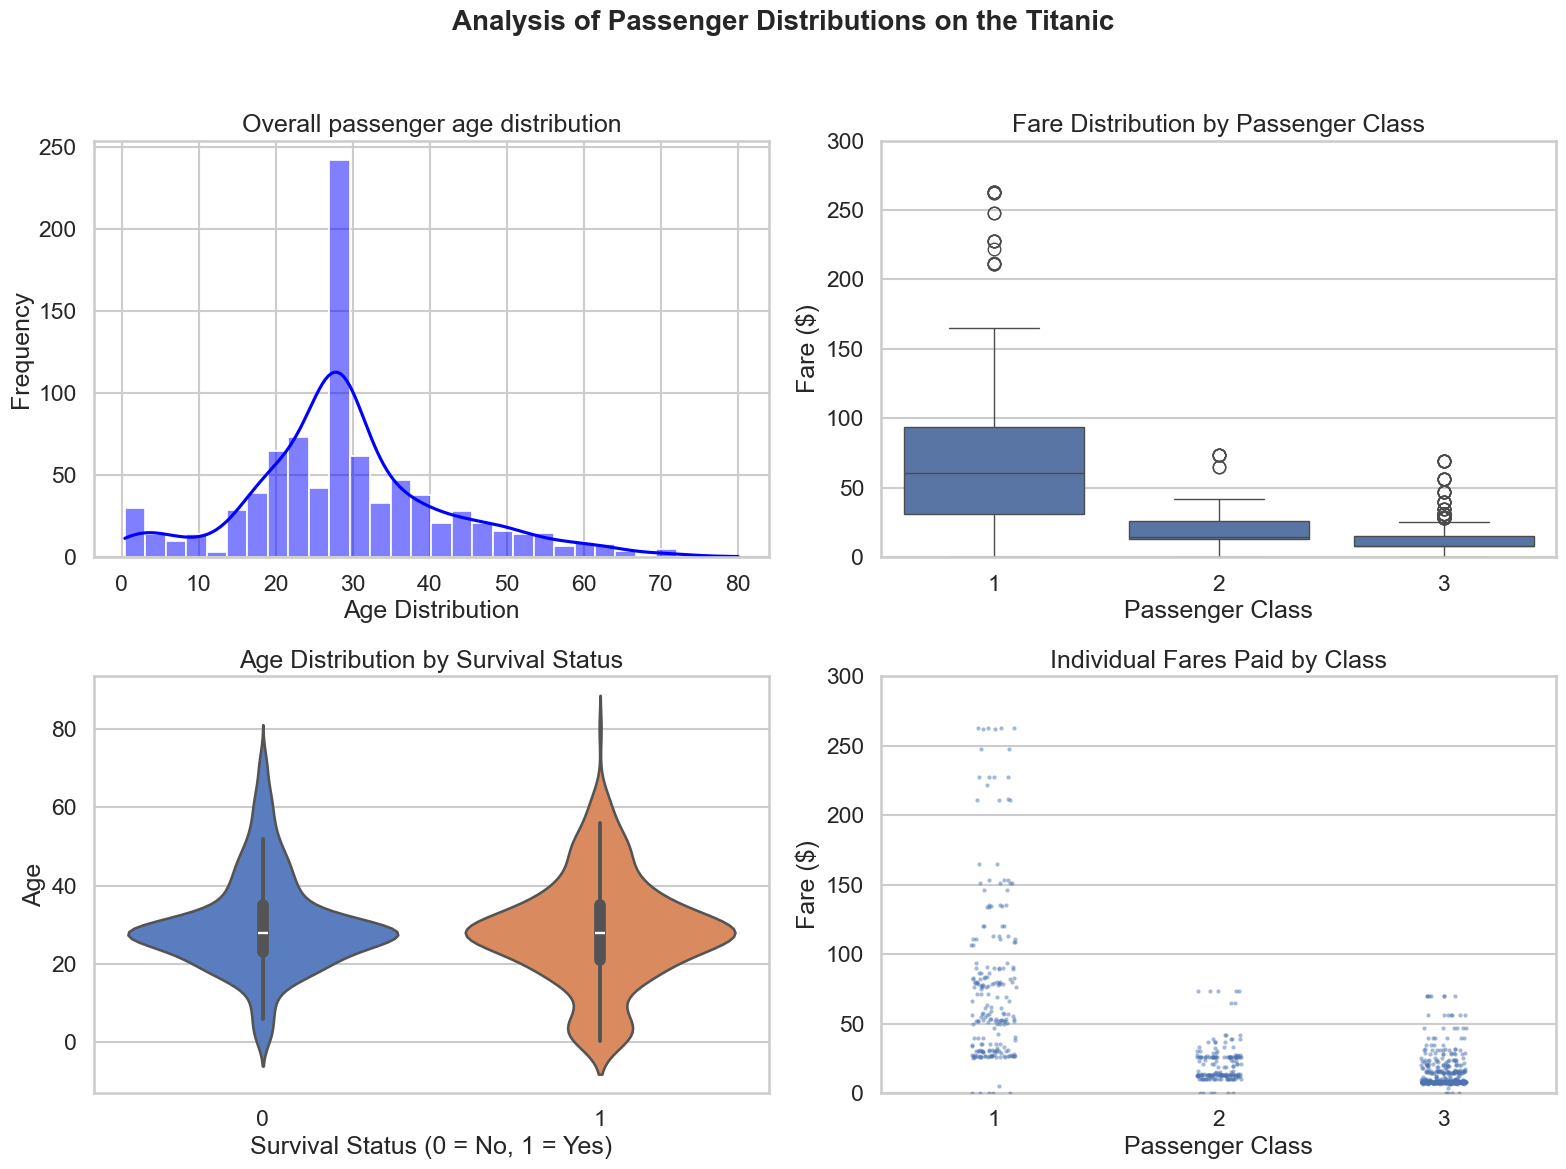

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
titanic = sns.load_dataset('titanic')

# A little data cleaning: 'age' has missing values. For this exercise, let's fill them.
# A simple strategy is to fill with the median age.
titanic['age'] = titanic['age'].fillna(titanic['age'].median())

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Add a single, overarching title for the entire figure
fig.suptitle('Analysis of Passenger Distributions on the Titanic', fontsize=20, fontweight='bold')

ax1 = axes[0,0]  # Grab the top left axis

sns.histplot(data=titanic,x ='age',ax=ax1,color='blue',kde=True)
ax1.set_title('Overall passenger age distribution')
ax1.set_xlabel('Age Distribution')
ax1.set_ylabel('Frequency')
# For overall distribution of a single column we do histrogram


# Box Plot, as it's excellent for comparing distributions across several categories.
ax2 = axes[0,1]
sns.boxplot(data=titanic , x='pclass' , y='fare', ax= ax2)
ax2.set_title('Fare Distribution by Passenger Class')
ax2.set_xlabel('Passenger Class')
ax2.set_ylabel('Fare ($)')
ax2.set_ylim(0, 300) # Zoom in to see the boxes more clearly, cutting off extreme outliers


ax3 = axes[1, 0] # Grab the bottom-left axes
sns.violinplot(data=titanic, x='survived', y='age', ax=ax3, palette='muted')
ax3.set_title('Age Distribution by Survival Status')
ax3.set_xlabel('Survival Status (0 = No, 1 = Yes)')
ax3.set_ylabel('Age')


ax4 = axes[1, 1] # Grab the bottom-right axes
sns.stripplot(data=titanic, x='pclass', y='fare', ax=ax4, jitter=True, alpha=0.5, size=3)
ax4.set_title('Individual Fares Paid by Class')
ax4.set_xlabel('Passenger Class')
ax4.set_ylabel('Fare ($)')
ax4.set_ylim(0, 300)# Zoom in to see the boxes more clearly, cutting off extreme outliers

fig.tight_layout(rect=[0, 0, 1, 0.96]) # rect is used to make space for the suptitle


plt.show()



  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


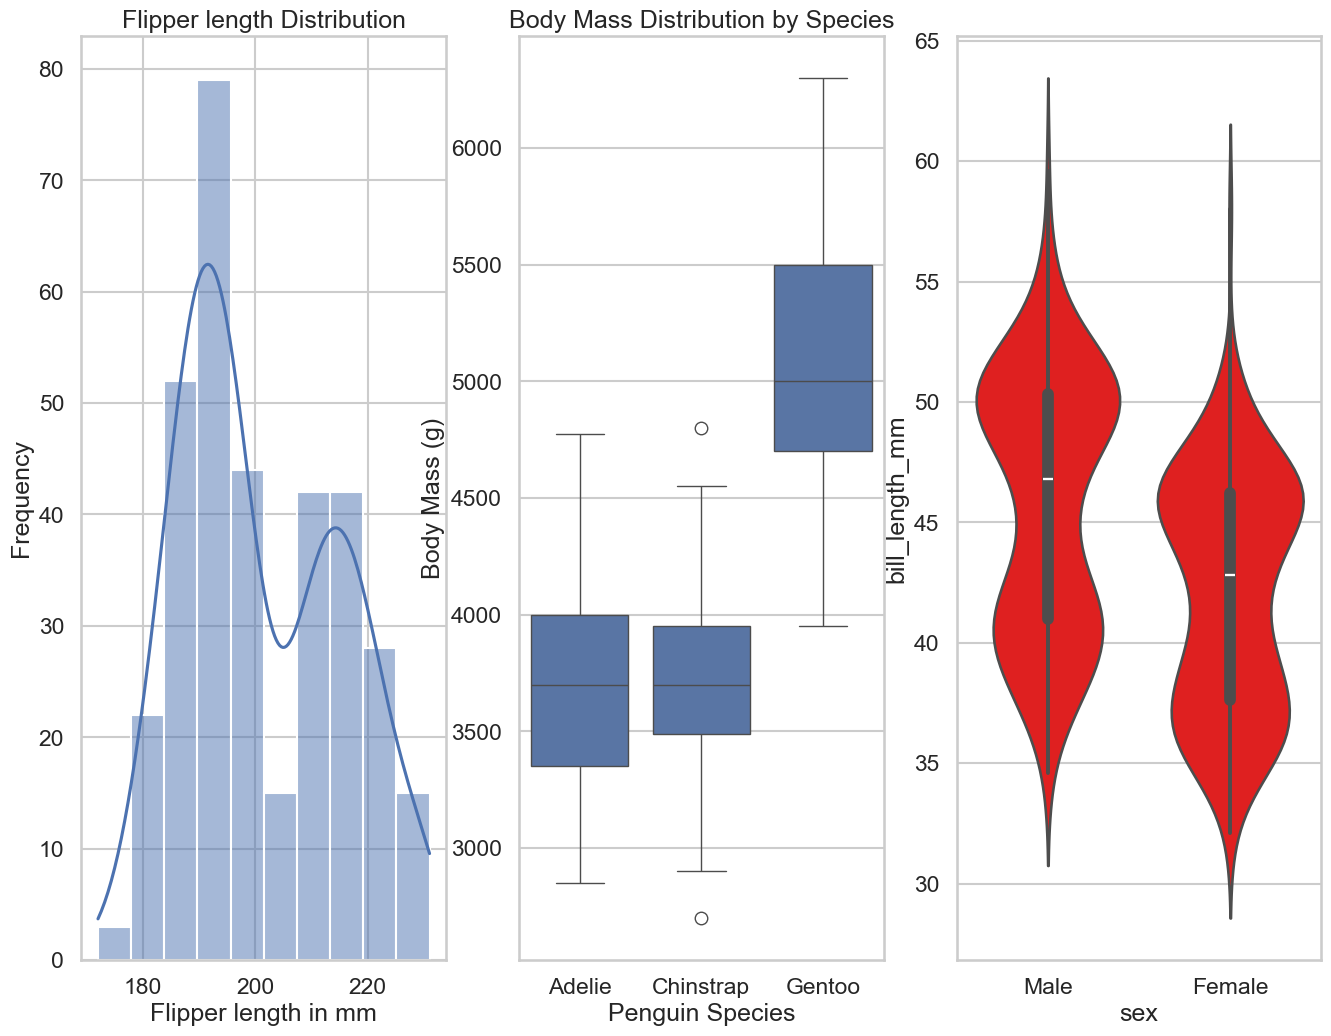

In [65]:
fig ,axes = plt.subplots(1, 3 ,figsize=(16,12))

penguins = sns.load_dataset('penguins')


ax1 = axes[0]

sns.histplot(data=penguins , ax = ax1 , x='flipper_length_mm',kde=True)
ax1.set_title('Flipper length Distribution')
ax1.set_xlabel('Flipper length in mm')
ax1.set_ylabel('Frequency')

# in histogram if we have multiple peak plot  kde it means it multi modal

# compare a numerical distribution across several categories, what's our go-to tool? A Box Plot.

# ax2 = axes[1]
# sns.stripplot(data = penguins , ax=ax2,x='species' , y='body_mass_g',color='blue')
ax2 = axes[1]
sns.boxplot(data=penguins, ax=ax2, x='species', y='body_mass_g')
ax2.set_title('Body Mass Distribution by Species')
ax2.set_xlabel('Penguin Species')
ax2.set_ylabel('Body Mass (g)')


ax3 = axes[2]
sns.violinplot(data=penguins , ax= ax3 , x='sex' , y='bill_length_mm',color='red' )
print(penguins.head())


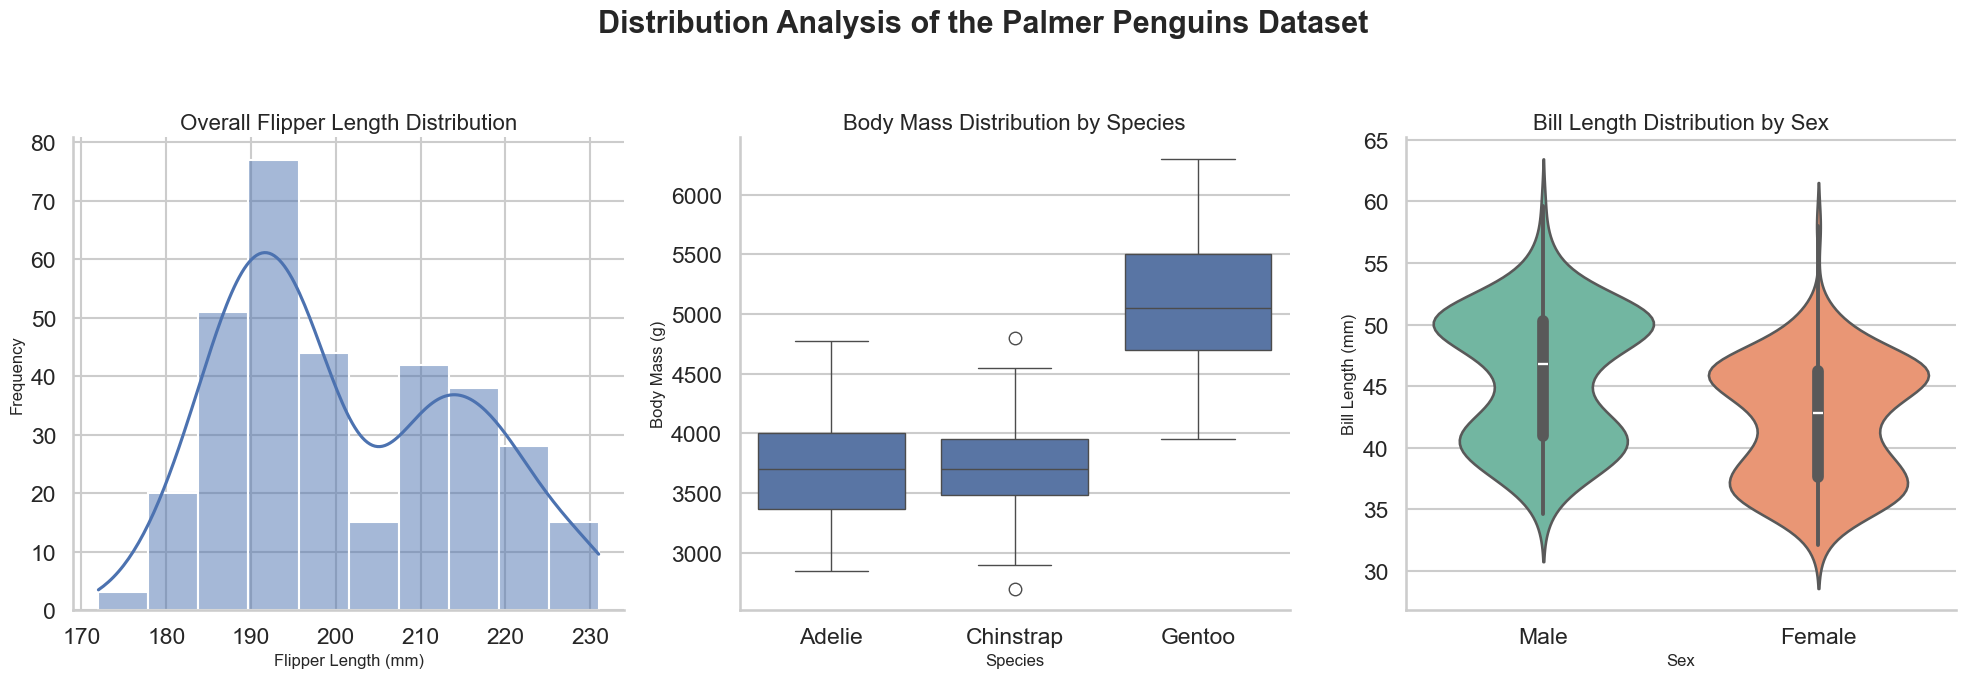

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
penguins = sns.load_dataset('penguins')
# Drop rows with missing data for this exercise
penguins.dropna(inplace=True)

# 1. SETUP: Create the 1x3 grid
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Distribution Analysis of the Palmer Penguins Dataset', fontsize=22, fontweight='bold')

# --- Plot 1: Flipper Length Distribution ---
ax1 = axes[0]
sns.histplot(data=penguins, ax=ax1, x='flipper_length_mm', kde=True)
ax1.set_title('Overall Flipper Length Distribution', fontsize=16)
ax1.set_xlabel('Flipper Length (mm)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)

# --- Plot 2: Body Mass by Species (Revised with Box Plot) ---
ax2 = axes[1]
sns.boxplot(data=penguins, ax=ax2, x='species', y='body_mass_g')
ax2.set_title('Body Mass Distribution by Species', fontsize=16)
ax2.set_xlabel('Species', fontsize=12)
ax2.set_ylabel('Body Mass (g)', fontsize=12)

# --- Plot 3: Bill Length by Sex ---
ax3 = axes[2]
sns.violinplot(data=penguins, ax=ax3, x='sex',hue='sex', y='bill_length_mm', palette='Set2',legend=False)
ax3.set_title('Bill Length Distribution by Sex', fontsize=16)
ax3.set_xlabel('Sex', fontsize=12)
ax3.set_ylabel('Bill Length (mm)', fontsize=12)

# Final Polish
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust for suptitle
plt.show()

fig.savefig('penguins_distribution_dashboard.png', dpi=300)

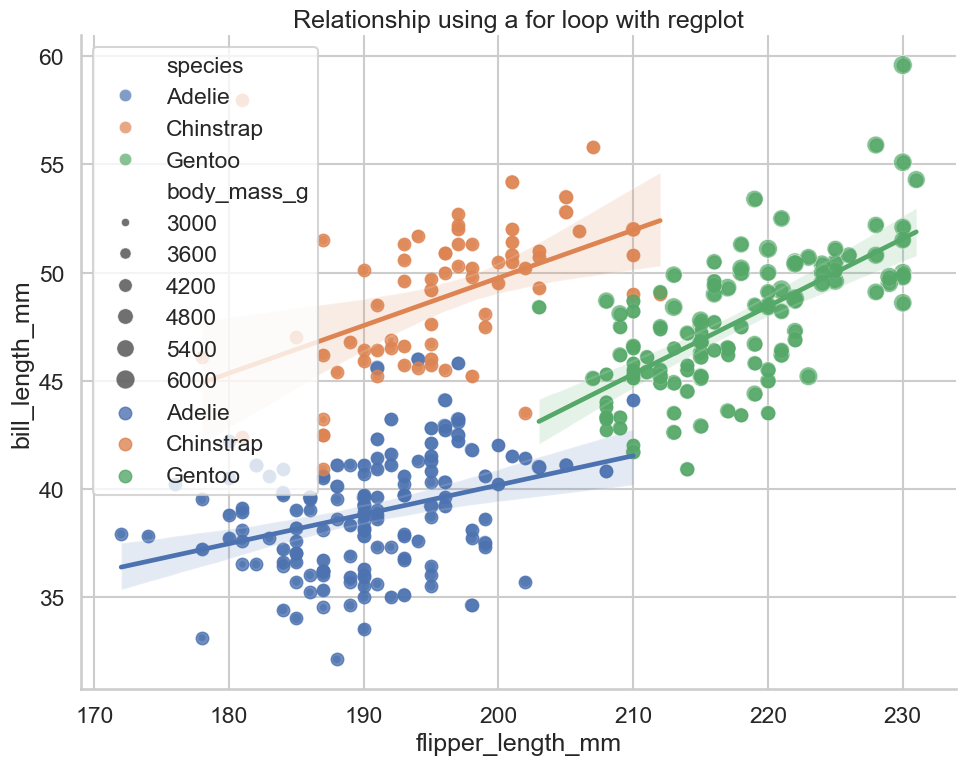

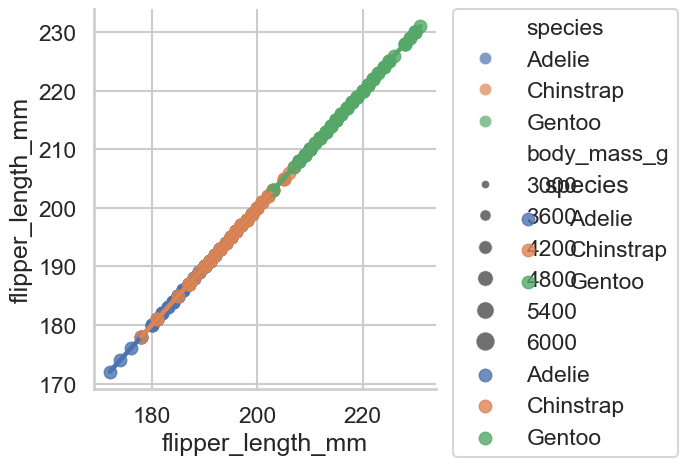

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset and drop missing values for simplicity
penguins = sns.load_dataset('penguins')
penguins.dropna(inplace=True)

# Set a nice theme
sns.set_theme(style="whitegrid", context="talk")

fig, ax = plt.subplots(figsize=(10, 8))
scatter = sns.scatterplot(data=penguins, x='flipper_length_mm', y='bill_length_mm', ax=ax,hue='species',size='body_mass_g',sizes=(20, 200),alpha=0.7)
ax.set_title('Relationship between Flipper Length and Bill Length')
ax.set_xlabel('Flipper Length (mm)')
ax.set_ylabel('Bill Length (mm)')




species_list = penguins['species'].unique()


for species in species_list:
    subset = penguins[penguins['species'] == species] # This is for filtered of species
    sns.regplot(data=subset, x='flipper_length_mm', y='bill_length_mm', ax=ax, label=species)

ax.set_title('Relationship using a for loop with regplot')

# so implot is a figure level function so it will always create a new figure but regplot is axes level function and it will
# create the figure whiever axi swe want we have that freedom

sns.lmplot(data=penguins, x='flipper_length_mm', y='flipper_length_mm', hue='species')

ax.legend()
h, l = scatter.get_legend_handles_labels()
plt.legend(h, l, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
# What hue does is that it makes the different groups of that hue columns
plt.show()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


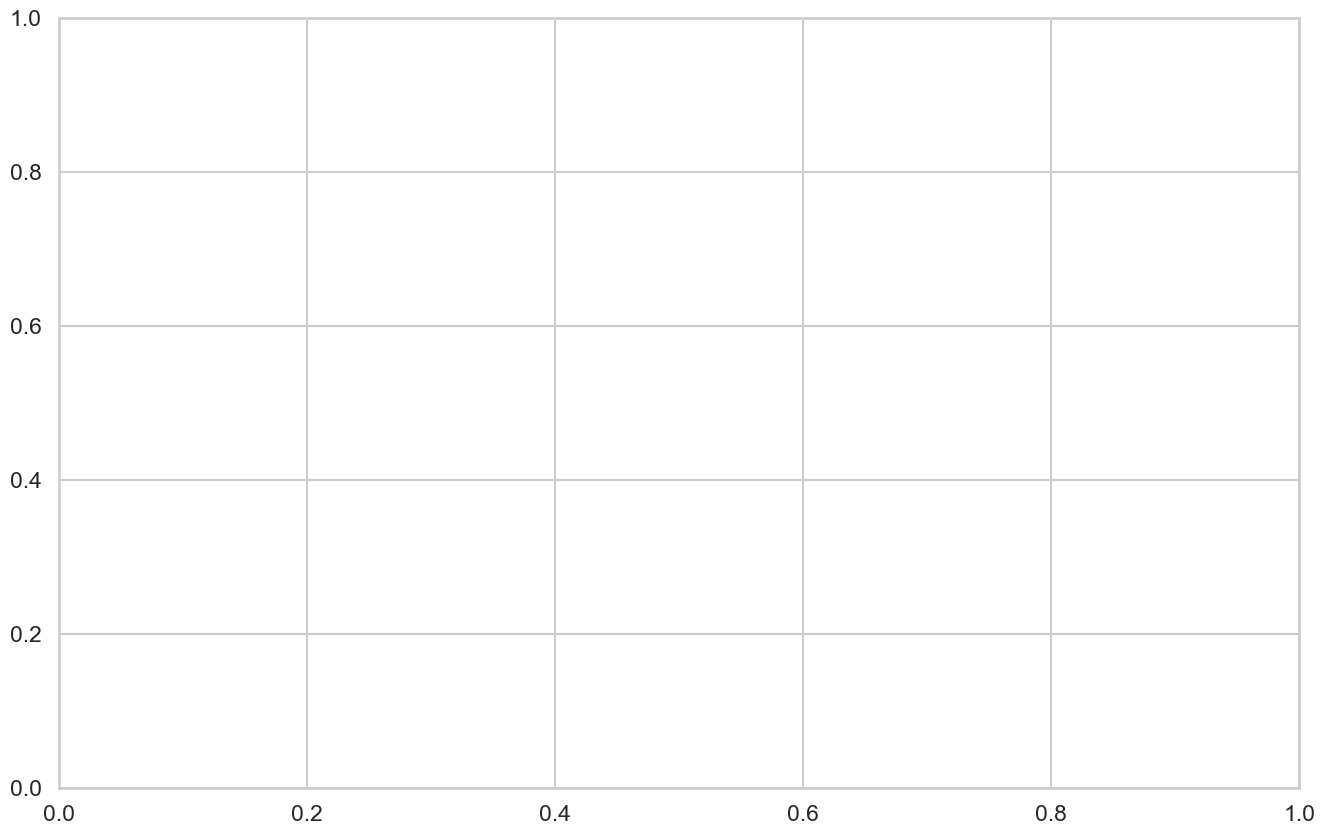

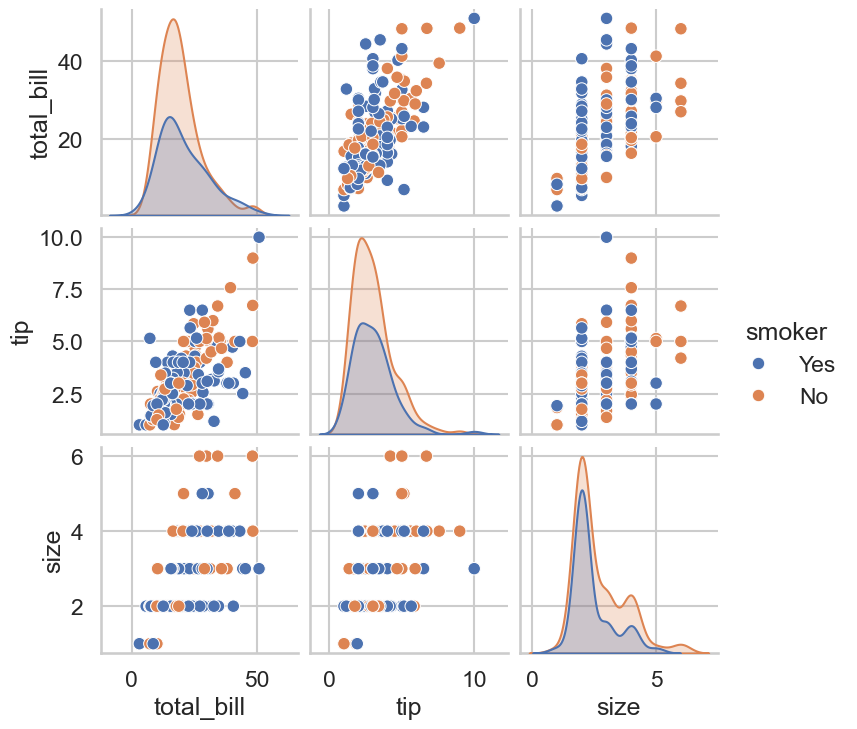

In [68]:
tips = sns.load_dataset('tips')

fig, ax = plt.subplots(figsize=(16,10))

sns.pairplot(data=tips,hue='smoker') 
# just to get the intial view of reltionshiop b/w variable

tips.head()

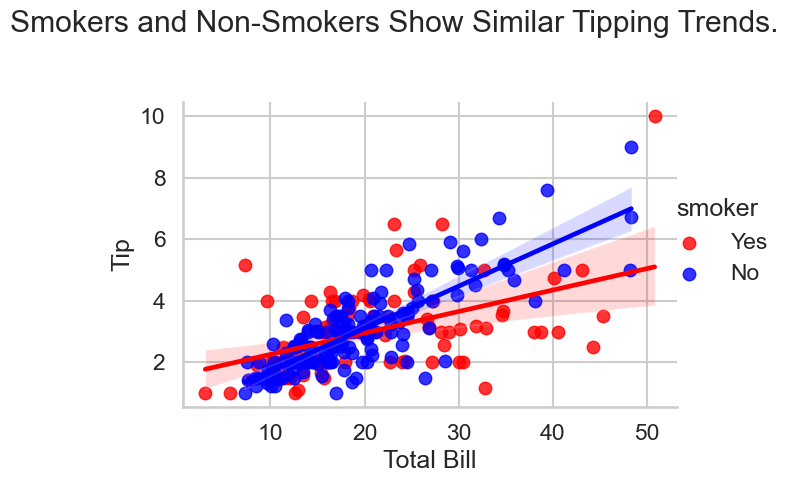

In [74]:
sns.lmplot(data=tips, x= 'total_bill' , y='tip' , hue='smoker',palette={'Yes': 'red', 'No': 'blue'})
# lmplot creates its own Figure, so you can't use ax.set_title()
plt.suptitle("Smokers and Non-Smokers Show Similar Tipping Trends.")
plt.ylabel('Tip')
plt.xlabel('Total Bill')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()